In [4]:
library(tidyverse)
library(lme4)
library(lmerTest)
library(emmeans)
library(broom.mixed)

In [5]:
# --------------------------------------------------
# Load processed neural-behavior dataframe
# --------------------------------------------------

df <- read_csv(
    
    "C:/Users/sjs93/OneDrive/Documents/GitHub/diff_fam_social_memory_ephys/other_peoples_sutff/sequioa/Phase1_hab_dis_rank_GLM/lfp_kinematics_habit_dishabit_relative_rank_COMPLETE.csv"
)

# inspect dataframe
glimpse(df)

Rows: 340375 Columns: 27
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (8): recording, event, partner, condition, band, metric, region_or_pair...
dbl (19): Unnamed: 0, subject, trial, event_length, distance, velocity_mouse...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 340,375
Columns: 27
$ `Unnamed: 0`             <dbl> 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,…
$ subject                  <dbl> 1.1, 1.1, 1.1, 1.1, 1.1, 1.1, 1.1, 1.1, 1.1, …
$ recording                <chr> "11_cage_p1_merged.rec", "11_cage_p1_merged.r…
$ event                    <chr> "exp1 sniff", "exp1 sniff", "exp1 sniff", "ex…
$ partner                  <chr> "A", "A", "A", "A", "A", "A", "A", "A", "A", …
$ trial                    <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ condition                <chr> "cagemate", "cagemate", "cagemate", "cagemate…
$ event_length             <dbl> 3656, 3656, 3656, 3656, 3656, 3656, 3656, 365…
$ distance                 <dbl> 275.7197, 275.7197, 275.7197, 275.7197, 275.7…
$ velocity_mouse1          <dbl> 0.2805405, 0.2805405, 0.2805405, 0.2805405, 0…
$ velocity_mouse2          <dbl> 0.225348, 0.225348, 0.225348, 0.225348, 0.225…
$ moving_angle_mouse1      <dbl> -6.406927, -6.406927, -6.406927, -6.406927, -…
$ moving_angle

In [6]:
# --------------------------------------------------
# Keep only coherence rows
# --------------------------------------------------

coh_df <- df |>
    
    filter(metric == "coherence")

In [4]:
# --------------------------------------------------
# Get all unique region pairs
# --------------------------------------------------

region_pairs <- unique(
    coh_df$region_or_pair
)

region_pairs

[1] "mPFC_NAc"  "mPFC_MD"   "mPFC_BLA"  "mPFC_vHPC" "NAc_MD"    "NAc_BLA"  
 [7] "NAc_vHPC"  "MD_BLA"    "MD_vHPC"   "BLA_vHPC"

In [10]:
table(
    coh_df$condition,
    coh_df$relative_rank,
    useNA = "ifany"
)

          
           equal_rank higher_than_subject lower_than_subject
  cagemate       1550               21600              19150
  novel          3250               28150              23550

In [5]:
# --------------------------------------------------
# Run mixed-effects models across all region pairs
#
# This loop tests whether coherence differs as a
# function of:
# - relative social hierarchy
# - oscillatory frequency band
# - their interaction
#
# while controlling for:
# - subject movement velocity
# - sniff-event duration
#
# and accounting for repeated sampling within
# recording sessions using a random intercept:
#
#     (1 | recording)
#
# The analysis is repeated separately for each
# inter-regional coherence pair
# (e.g., mPFC_MD, BLA_vHPC, NAc_MD).
#
# For each region pair:
# 1. subset coherence rows
# 2. fit mixed-effects model
# 3. compute Type III ANOVA table
# 4. store results for downstream summaries
# --------------------------------------------------

# get all unique coherence region pairs
region_pairs <- unique(
    coh_df$region_or_pair
)

# initialize empty list to store ANOVA tables
results_list <- list()

# loop through each region pair
for (pair in region_pairs) {

    cat("\n=========================\n")
    cat("Running:", pair, "\n")
    cat("=========================\n")

    # subset dataframe for one region pair
    test_df <- coh_df |>
        
        filter(region_or_pair == pair)

    # fit mixed-effects model
    mixed_model <- lmer(
        
        value ~
            relative_rank * band +
            velocity_mouse1 +
            event_length +
            (1 | recording),

        data = test_df
    )

    # compute Type III ANOVA table
    model_anova <- anova(mixed_model)

    # store ANOVA results
    results_list[[pair]] <- model_anova

    # print ANOVA table to console
    print(model_anova)
}


Running: mPFC_NAc 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank       1346.1   673.0     2 3461.2  3.1560 0.0427188 *  
band               25761.1  6440.3     4 7346.1 30.1994 < 2.2e-16 ***
velocity_mouse1     2955.7  2955.7     1 7362.8 13.8596 0.0001985 ***
event_length         236.4   236.4     1 7362.5  1.1087 0.2924060    
relative_rank:band 19526.9  2440.9     8 7346.1 11.4456 2.865e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: mPFC_MD 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank        870.8   435.4     2 2433.9  1.6234 0.1974348    
band               13653.7  3413.4     4 7556.4 12.7274 2.523e-10 ***
velocity_mouse1      120.2   120.2     1 7567.2  0.4484 0.5031312    
event_length        2435.5  2435.5     1 7572.0  9.0809 0.0025914 ** 
relative_rank:band  7977.9   997.2     8 7556.4  3.7184 0.0002388 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: mPFC_BLA 


...

Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank       8362.0  4181.0     2 2424.5 23.5638 7.321e-11 ***
band                 691.8   172.9     4 8085.3  0.9747    0.4199    
velocity_mouse1     3040.2  3040.2     1 8092.8 17.1342 3.518e-05 ***
event_length         128.9   128.9     1 8102.5  0.7263    0.3941    
relative_rank:band 19193.5  2399.2     8 8085.3 13.5217 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: MD_vHPC 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                   Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank      6205.0 3102.52     2 2500.7 11.9890 6.577e-06 ***
band               2821.1  705.29     4 6160.0  2.7254   0.02778 *  
velocity_mouse1     938.0  937.97     1 6173.0  3.6246   0.05698 .  
event_length         27.9   27.89     1 6170.3  0.1078   0.74271    
relative_rank:band 8311.8 1038.97     8 6160.0  4.0149 9.120e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: BLA_vHPC 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank        183.0    91.5     2 1730.4  0.3316  0.717815    
band                4724.0  1181.0     4 5607.3  4.2808  0.001848 ** 
velocity_mouse1     5212.7  5212.7     1 5614.2 18.8945 1.406e-05 ***
event_length        1176.5  1176.5     1 5617.0  4.2644  0.038965 *  
relative_rank:band 28938.6  3617.3     8 5607.3 13.1118 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [6]:
region_pairs <- unique(
    coh_df$region_or_pair
)

results_list <- list()

for (pair in region_pairs) {

    cat("\n=========================\n")
    cat("Running:", pair, "\n")
    cat("=========================\n")

    test_df <- coh_df |>
        
        filter(region_or_pair == pair)

    mixed_model <- lmer(
        
        value ~
            relative_rank * band +
            velocity_mouse1 +
            event_length +
            (1 | recording),

        data = test_df
    )

    model_anova <- anova(mixed_model)

    results_list[[pair]] <- model_anova

    print(model_anova)
}


Running: mPFC_NAc 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank       1346.1   673.0     2 3461.2  3.1560 0.0427188 *  
band               25761.1  6440.3     4 7346.1 30.1994 < 2.2e-16 ***
velocity_mouse1     2955.7  2955.7     1 7362.8 13.8596 0.0001985 ***
event_length         236.4   236.4     1 7362.5  1.1087 0.2924060    
relative_rank:band 19526.9  2440.9     8 7346.1 11.4456 2.865e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: mPFC_MD 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank        870.8   435.4     2 2433.9  1.6234 0.1974348    
band               13653.7  3413.4     4 7556.4 12.7274 2.523e-10 ***
velocity_mouse1      120.2   120.2     1 7567.2  0.4484 0.5031312    
event_length        2435.5  2435.5     1 7572.0  9.0809 0.0025914 ** 
relative_rank:band  7977.9   997.2     8 7556.4  3.7184 0.0002388 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: mPFC_BLA 


...

Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank       8362.0  4181.0     2 2424.5 23.5638 7.321e-11 ***
band                 691.8   172.9     4 8085.3  0.9747    0.4199    
velocity_mouse1     3040.2  3040.2     1 8092.8 17.1342 3.518e-05 ***
event_length         128.9   128.9     1 8102.5  0.7263    0.3941    
relative_rank:band 19193.5  2399.2     8 8085.3 13.5217 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: MD_vHPC 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                   Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank      6205.0 3102.52     2 2500.7 11.9890 6.577e-06 ***
band               2821.1  705.29     4 6160.0  2.7254   0.02778 *  
velocity_mouse1     938.0  937.97     1 6173.0  3.6246   0.05698 .  
event_length         27.9   27.89     1 6170.3  0.1078   0.74271    
relative_rank:band 8311.8 1038.97     8 6160.0  4.0149 9.120e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Running: BLA_vHPC 


Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


Type III Analysis of Variance Table with Satterthwaite's method
                    Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
relative_rank        183.0    91.5     2 1730.4  0.3316  0.717815    
band                4724.0  1181.0     4 5607.3  4.2808  0.001848 ** 
velocity_mouse1     5212.7  5212.7     1 5614.2 18.8945 1.406e-05 ***
event_length        1176.5  1176.5     1 5617.0  4.2644  0.038965 *  
relative_rank:band 28938.6  3617.3     8 5607.3 13.1118 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [7]:
# --------------------------------------------------
# Extract relative-rank p-values across region pairs
# --------------------------------------------------

summary_df <- tibble()

for (pair in names(results_list)) {

    anova_table <- results_list[[pair]]

    pval <- anova_table[
        "relative_rank",
        "Pr(>F)"
    ]

    summary_df <- bind_rows(
        
        summary_df,
        
        tibble(
            region_pair = pair,
            relative_rank_pvalue = pval
        )
    )
}

summary_df

region_pair,relative_rank_pvalue
<chr>,<dbl>
mPFC_NAc,4.271876e-02
mPFC_MD,1.974348e-01
mPFC_BLA,1.922831e-01
mPFC_vHPC,3.014602e-01
NAc_MD,1.385392e-13
NAc_BLA,1.776691e-02
NAc_vHPC,3.784127e-04
MD_BLA,7.320514e-11
MD_vHPC,6.577421e-06


In [8]:
# --------------------------------------------------
# Create slide-style summary table
# --------------------------------------------------

slide_table <- summary_df |>
    
    arrange(relative_rank_pvalue) |>
    
    mutate(
        
        p_value =
            ifelse(
                relative_rank_pvalue < 0.001,
                "< 0.001",
                round(relative_rank_pvalue, 3)
            )
    ) |>
    
    select(
        region_pair,
        p_value
    )

slide_table

region_pair,p_value
<chr>,<chr>
NAc_MD,< 0.001
MD_BLA,< 0.001
MD_vHPC,< 0.001
NAc_vHPC,< 0.001
NAc_BLA,0.018
mPFC_NAc,0.043
mPFC_BLA,0.192
mPFC_MD,0.197
mPFC_vHPC,0.301


In [9]:
# --------------------------------------------------
# Keep only significant region pairs
# --------------------------------------------------

slide_table <- summary_df |>
    
    filter(relative_rank_pvalue < 0.05) |>
    
    arrange(relative_rank_pvalue) |>
    
    mutate(
        
        p_value =
            ifelse(
                relative_rank_pvalue < 0.001,
                "< 0.001",
                sprintf("%.3f", relative_rank_pvalue)
            )
    ) |>
    
    select(
        Region_Pair = region_pair,
        p_value
    )

slide_table

Region_Pair,p_value
<chr>,<chr>
NAc_MD,< 0.001
MD_BLA,< 0.001
MD_vHPC,< 0.001
NAc_vHPC,< 0.001
NAc_BLA,0.018
mPFC_NAc,0.043


In [10]:
# --------------------------------------------------
# Extract p-values across region pairs
# --------------------------------------------------

summary_df <- tibble()

for (pair in names(results_list)) {

    anova_table <- results_list[[pair]]

    # main hierarchy effect
    rank_pval <- anova_table[
        "relative_rank",
        "Pr(>F)"
    ]

    # hierarchy × band interaction
    interaction_pval <- anova_table[
        "relative_rank:band",
        "Pr(>F)"
    ]

    summary_df <- bind_rows(
        
        summary_df,
        
        tibble(
            region_pair = pair,
            relative_rank_pvalue = rank_pval,
            interaction_pvalue = interaction_pval
        )
    )
}

summary_df

region_pair,relative_rank_pvalue,interaction_pvalue
<chr>,<dbl>,<dbl>
mPFC_NAc,4.271876e-02,2.865070e-16
mPFC_MD,1.974348e-01,2.387771e-04
mPFC_BLA,1.922831e-01,1.897501e-10
mPFC_vHPC,3.014602e-01,2.037324e-14
NAc_MD,1.385392e-13,1.563175e-09
NAc_BLA,1.776691e-02,1.894644e-01
NAc_vHPC,3.784127e-04,1.841884e-08
MD_BLA,7.320514e-11,1.244281e-19
MD_vHPC,6.577421e-06,9.120151e-05


In [11]:
# --------------------------------------------------
# Keep only MD_BLA coherence rows
#
# We are now focusing on a single circuit for
# detailed follow-up analysis.
# --------------------------------------------------

test_df <- coh_df |>
    
    filter(region_or_pair == "MD_BLA")

In [12]:
# inspect hierarchy-condition counts

table(test_df$relative_rank)

# inspect frequency-band counts

table(test_df$band)


         equal_rank higher_than_subject  lower_than_subject 
                480                4975                4270 


      Beta      Delta High gamma  Low gamma      Theta 
      1945       1945       1945       1945       1945 

In [13]:
# --------------------------------------------------
# Fit mixed-effects model
#
# Tests whether MD_BLA coherence differs
# depending on:
# - hierarchy relationship
# - oscillatory frequency band
# - their interaction
#
# while controlling for:
# - movement velocity
# - sniff duration
#
# and accounting for repeated samples
# within recording sessions.
# --------------------------------------------------

model <- lmer(
    
    value ~
        relative_rank * band +
        velocity_mouse1 +
        event_length +
        (1 | recording),

    data = test_df
)

Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


In [14]:
# --------------------------------------------------
# View Type III ANOVA table
# --------------------------------------------------

anova(model)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
relative_rank,8361.9870,4180.9935,2,2424.522,23.5638466,7.320514e-11
band,691.7880,172.9470,4,8085.269,0.9747196,4.199276e-01
velocity_mouse1,3040.1654,3040.1654,1,8092.775,17.1342028,3.518273e-05
event_length,128.8605,128.8605,1,8102.533,0.7262508,3.941263e-01
relative_rank:band,19193.4988,2399.1874,8,8085.269,13.5216864,1.244281e-19


In [15]:
# --------------------------------------------------
# Compute estimated marginal means (EMMs)
#
# Estimates model-predicted coherence values
# for each hierarchy condition within each
# frequency band.
# --------------------------------------------------

emm <- emmeans(
    
    model,
    
    ~ relative_rank | band
)

emm

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 8120' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 8120)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 8120' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 8120)' or larger];
but be warned that this may result in large computation time and memory use.



band = Beta:
 relative_rank        emmean   SE  df asymp.LCL asymp.UCL
 equal_rank           -0.321 1.95 Inf     -4.15     3.506
 higher_than_subject -10.627 1.15 Inf    -12.89    -8.368
 lower_than_subject   -2.373 1.14 Inf     -4.60    -0.143

band = Delta:
 relative_rank        emmean   SE  df asymp.LCL asymp.UCL
 equal_rank           -4.611 1.95 Inf     -8.44    -0.784
 higher_than_subject  -3.705 1.15 Inf     -5.96    -1.446
 lower_than_subject   -1.217 1.14 Inf     -3.45     1.013

band = High gamma:
 relative_rank        emmean   SE  df asymp.LCL asymp.UCL
 equal_rank            0.975 1.95 Inf     -2.85     4.802
 higher_than_subject -10.121 1.15 Inf    -12.38    -7.862
 lower_than_subject   -4.771 1.14 Inf     -7.00    -2.541

band = Low gamma:
 relative_rank        emmean   SE  df asymp.LCL asymp.UCL
 equal_rank            1.739 1.95 Inf     -2.09     5.567
 higher_than_subject -10.421 1.15 Inf    -12.68    -8.162
 lower_than_subject   -2.977 1.14 Inf     -5.21    -0.747

band

In [16]:
# --------------------------------------------------
# Pairwise hierarchy comparisons within each band
# --------------------------------------------------

pairs(emm)

band = Beta:
 contrast                                 estimate    SE  df z.ratio p.value
 equal_rank - higher_than_subject           10.306 1.880 Inf   5.484 <0.0001
 equal_rank - lower_than_subject             2.053 1.720 Inf   1.193  0.4576
 higher_than_subject - lower_than_subject   -8.254 0.983 Inf  -8.400 <0.0001

band = Delta:
 contrast                                 estimate    SE  df z.ratio p.value
 equal_rank - higher_than_subject           -0.907 1.880 Inf  -0.482  0.8796
 equal_rank - lower_than_subject            -3.395 1.720 Inf  -1.972  0.1191
 higher_than_subject - lower_than_subject   -2.488 0.983 Inf  -2.532  0.0305

band = High gamma:
 contrast                                 estimate    SE  df z.ratio p.value
 equal_rank - higher_than_subject           11.096 1.880 Inf   5.904 <0.0001
 equal_rank - lower_than_subject             5.746 1.720 Inf   3.339  0.0024
 higher_than_subject - lower_than_subject   -5.350 0.983 Inf  -5.445 <0.0001

band = Low gamma:
 contrast

In [17]:
# --------------------------------------------------
# Convert EMM results into dataframe for plotting
# --------------------------------------------------

emm_df <- as.data.frame(emm)

In [18]:
# inspect dataframe

head(emm_df)

,relative_rank,band,emmean,SE,df,asymp.LCL,asymp.UCL
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,equal_rank,Beta,-0.3208843,1.952626,Inf,-4.147962,3.5061931
2,higher_than_subject,Beta,-10.6272963,1.152662,Inf,-12.886473,-8.3681198
3,lower_than_subject,Beta,-2.3734433,1.137800,Inf,-4.603490,-0.1433967
4,equal_rank,Delta,-4.6114618,1.952626,Inf,-8.438539,-0.7843843
5,higher_than_subject,Delta,-3.7047601,1.152662,Inf,-5.963937,-1.4455837
6,lower_than_subject,Delta,-1.2168470,1.137800,Inf,-3.446894,1.0131996


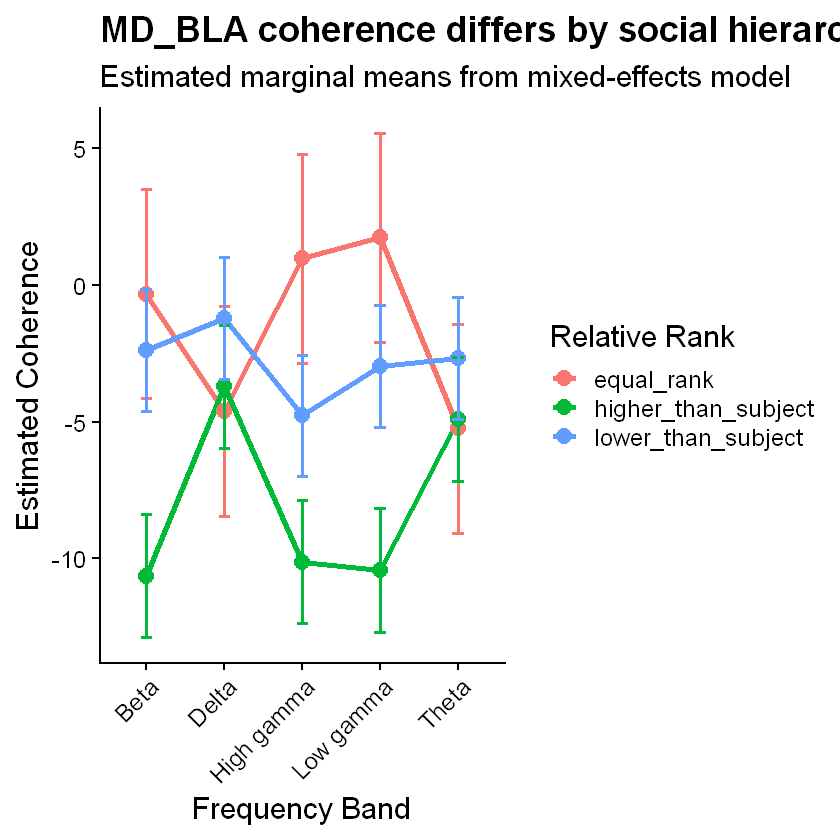

In [19]:
# --------------------------------------------------
# Plot estimated coherence by:
# - frequency band
# - hierarchy relationship
#
# These are model-adjusted means from the
# mixed-effects model.
# --------------------------------------------------

ggplot(
    
    emm_df,
    
    aes(
        x = band,
        y = emmean,
        color = relative_rank,
        group = relative_rank
    )
) +

# connect points across bands
geom_line(
    linewidth = 1.5
) +

# mean points
geom_point(
    size = 4
) +

# confidence intervals
geom_errorbar(
    
    aes(
        ymin = asymp.LCL,
        ymax = asymp.UCL
    ),
    
    width = 0.15,
    linewidth = 1
) +

# labels
labs(
    
    title =
        "MD_BLA coherence differs by social hierarchy relationship",
    
    subtitle =
        "Estimated marginal means from mixed-effects model",
    
    x = "Frequency Band",
    
    y = "Estimated Coherence",
    
    color = "Relative Rank"
) +

# clean theme
theme_classic(
    base_size = 18
) +

theme(
    
    plot.title =
        element_text(face = "bold"),
    
    axis.text.x =
        element_text(angle = 45, hjust = 1)
)

In [20]:
# --------------------------------------------------
# Remove equal-rank interactions
#
# Focus analysis on:
# - higher-ranked partner interactions
# - lower-ranked partner interactions
# --------------------------------------------------

emm_df_filtered <- emm_df |>
    
    filter(
        relative_rank != "equal_rank"
    )

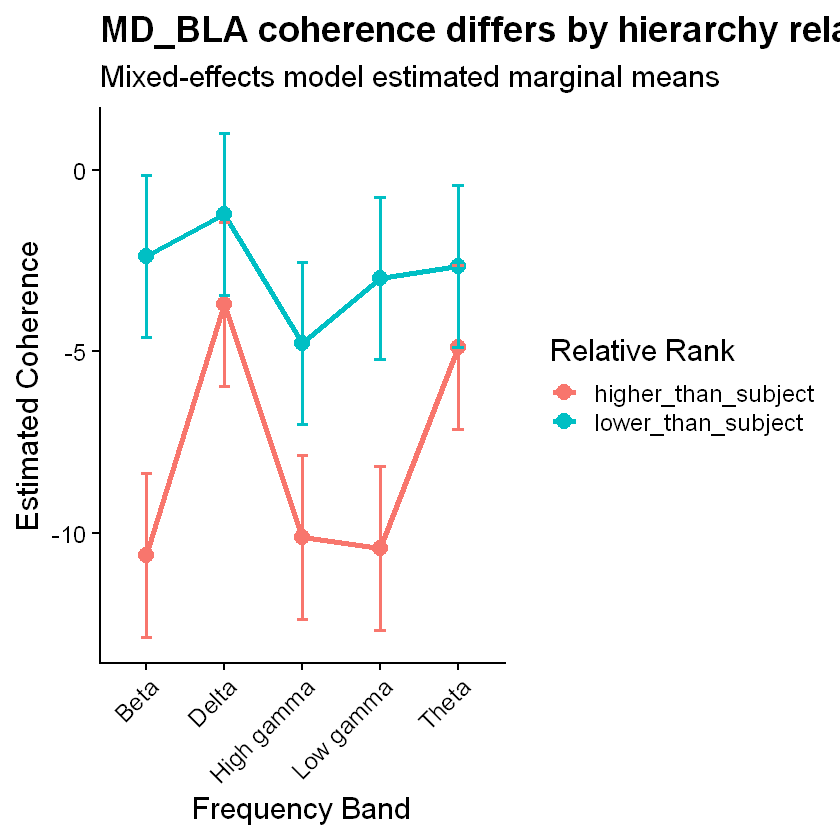

In [21]:
# --------------------------------------------------
# Plot hierarchy-dependent coherence
# after removing equal-rank interactions
# --------------------------------------------------

ggplot(
    
    emm_df_filtered,
    
    aes(
        x = band,
        y = emmean,
        color = relative_rank,
        group = relative_rank
    )
) +

# connect frequency-band estimates
geom_line(
    linewidth = 1.5
) +

# estimated marginal means
geom_point(
    size = 4
) +

# confidence intervals
geom_errorbar(
    
    aes(
        ymin = asymp.LCL,
        ymax = asymp.UCL
    ),
    
    width = 0.15,
    linewidth = 1
) +

# plot labels
labs(
    
    title =
        "MD_BLA coherence differs by hierarchy relationship",
    
    subtitle =
        "Mixed-effects model estimated marginal means",
    
    x = "Frequency Band",
    
    y = "Estimated Coherence",
    
    color = "Relative Rank"
) +

# clean plotting theme
theme_classic(
    base_size = 18
) +

theme(
    
    plot.title =
        element_text(face = "bold"),
    
    axis.text.x =
        element_text(angle = 45, hjust = 1)
)

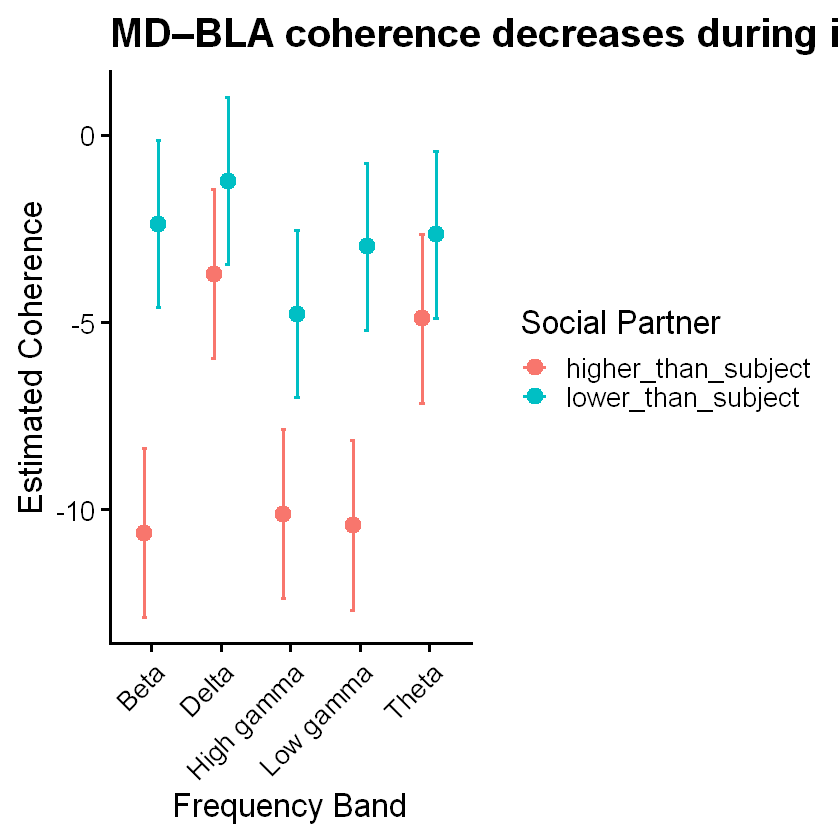

In [22]:
# --------------------------------------------------
# Plot estimated coherence by hierarchy condition
# without connecting lines
# --------------------------------------------------

ggplot(
    
    emm_df_filtered,
    
    aes(
        x = band,
        y = emmean,
        color = relative_rank
    )
) +

# estimated marginal means
geom_point(
    
    position =
        position_dodge(width = 0.4),
    
    size = 4
) +

# confidence intervals
geom_errorbar(
    
    aes(
        ymin = asymp.LCL,
        ymax = asymp.UCL
    ),
    
    position =
        position_dodge(width = 0.4),
    
    width = 0.15,
    linewidth = 1
) +

labs(
    
    title =
        "MD–BLA coherence decreases during interactions with dominant partners",
    
    x = "Frequency Band",
    
    y = "Estimated Coherence",
    
    color = "Social Partner"
) +

theme_classic(
    base_size = 20
) +

theme(
    
    plot.title =
        element_text(face = "bold"),
    
    axis.text.x =
        element_text(
            angle = 45,
            hjust = 1
        )
)

In [23]:
# --------------------------------------------------
# Reorder frequency bands
#
# Plot frequencies from low → high
# for easier biological interpretation
# --------------------------------------------------

emm_df_filtered$band <- factor(
    
    emm_df_filtered$band,
    
    levels = c(
        "Theta",
        "Delta",
        "Beta",
        "Low gamma",
        "High gamma"
    )
)

In [24]:
# --------------------------------------------------
# Rename hierarchy labels for cleaner plotting
# --------------------------------------------------

emm_df_filtered$relative_rank <- recode(
    
    emm_df_filtered$relative_rank,
    
    "higher_than_subject" =
        "Higher-ranked partner",
    
    "lower_than_subject" =
        "Lower-ranked partner"
)

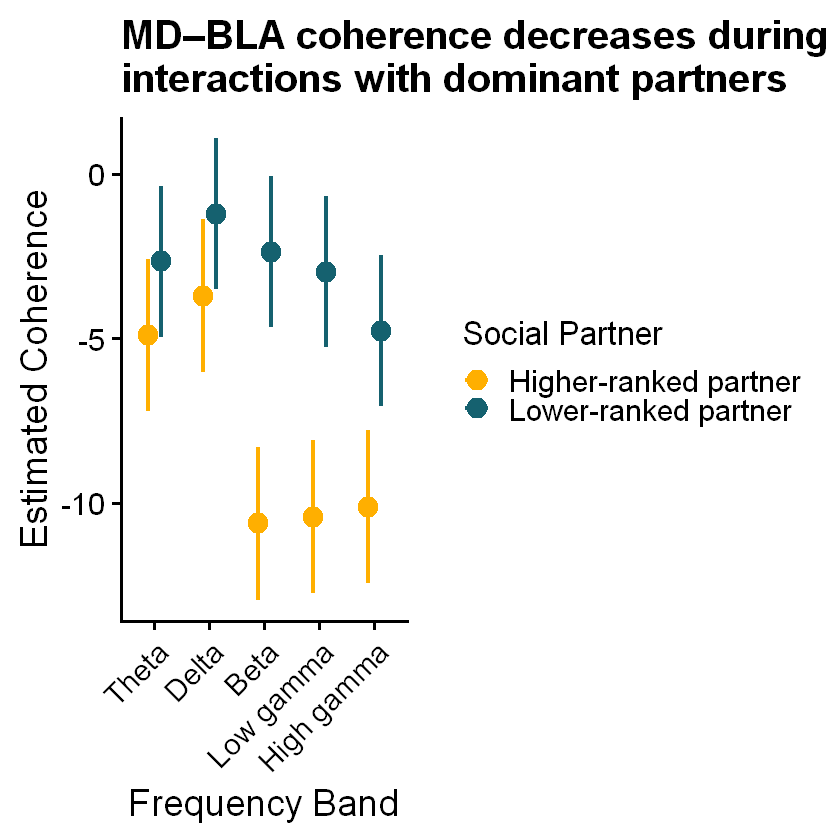

In [25]:
# --------------------------------------------------
# Plot model-estimated coherence values
#
# This visualization shows:
# - mixed-model estimated marginal means
# - confidence intervals
#
# comparing coherence during interactions with:
# - higher-ranked social partners
# - lower-ranked social partners
#
# across oscillatory frequency bands.
# --------------------------------------------------

# --------------------------------------------------
# Plot hierarchy-dependent MD_BLA coherence
# --------------------------------------------------

ggplot(
    
    emm_df_filtered,
    
    aes(
        x = band,
        y = emmean,
        color = relative_rank
    )
) +

# estimated marginal means
geom_point(
    
    position =
        position_dodge(width = 0.45),
    
    size = 5
) +

# confidence intervals
geom_errorbar(
    
    aes(
        ymin = asymp.LCL,
        ymax = asymp.UCL
    ),
    
    position =
        position_dodge(width = 0.45),
    
    width = 0.15,
    
    linewidth = 1.2
) +

# custom hierarchy colors
scale_color_manual(
    
    values = c(
        
        "Higher-ranked partner" = "#ffaf00",
        
        "Lower-ranked partner" = "#15616f"
    )
) +

# labels
labs(
    
    title =
        "MD–BLA coherence decreases during\ninteractions with dominant partners",
    
    x = "Frequency Band",
    
    y = "Estimated Coherence",
    
    color = "Social Partner"
) +

# clean theme
theme_classic(
    base_size = 22
) +

theme(
    
    # title formatting
    plot.title =
        element_text(
            face = "bold",
            size = 24
        ),
    
    # axis labels
    axis.title =
        element_text(
            size = 22
        ),
    
    # axis tick labels
    axis.text =
        element_text(
            size = 18,
            color = "black"
        ),
    
    # rotate x labels
    axis.text.x =
        element_text(
            angle = 45,
            hjust = 1
        ),
    
    # legend formatting
    legend.title =
        element_text(
            size = 20
        ),
    
    legend.text =
        element_text(
            size = 18
        ),
    
    # remove top/right borders
    panel.border =
        element_blank()
)

In [26]:
# --------------------------------------------------
# Subset NAc_MD data
# --------------------------------------------------

test_df <- coh_df |>
    
    filter(
        region_or_pair == "NAc_MD",
        relative_rank != "equal_rank"
    )

In [27]:
# --------------------------------------------------
# Keep only dominant/subordinate interactions
# --------------------------------------------------

test_df <- coh_df |>
    
    filter(
        region_or_pair == "NAc_MD",
        
        relative_rank != "equal_rank"
    )

In [28]:
# --------------------------------------------------
# Fit NAc_MD mixed model
# --------------------------------------------------

model <- lmer(
    
    value ~
        relative_rank * band +
        velocity_mouse1 +
        event_length +
        (1 | recording),

    data = test_df
)

Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


In [29]:
# --------------------------------------------------
# Type III ANOVA
# --------------------------------------------------

anova(model)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
relative_rank,8918.2778,8918.2778,1,2507.397,56.614466,7.344936e-14
band,41906.8919,10476.7230,4,7680.943,66.507692,2.101437e-55
velocity_mouse1,1816.5219,1816.5219,1,7697.698,11.531533,6.877158e-04
event_length,863.2098,863.2098,1,7696.899,5.479776,1.926312e-02
relative_rank:band,4884.5801,1221.1450,4,7680.943,7.751998,3.134731e-06


In [30]:
# --------------------------------------------------
# Compute NEW estimated marginal means
# --------------------------------------------------

emm <- emmeans(
    
    model,
    
    ~ relative_rank | band
)

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 7710' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 7710)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 7710' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 7710)' or larger];
but be warned that this may result in large computation time and memory use.



In [31]:
# --------------------------------------------------
# Convert emmeans to dataframe
# --------------------------------------------------

emm_df <- as.data.frame(emm)

In [32]:
emm_df

,relative_rank,band,emmean,SE,df,asymp.LCL,asymp.UCL
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,higher_than_subject,Beta,-6.4106537,1.383844,Inf,-9.122938,-3.698369
2,lower_than_subject,Beta,1.6186881,1.435026,Inf,-1.193911,4.431288
3,higher_than_subject,Delta,0.1020483,1.383844,Inf,-2.610236,2.814333
4,lower_than_subject,Delta,4.2540281,1.435026,Inf,1.441429,7.066628
5,higher_than_subject,High gamma,-6.7454269,1.383844,Inf,-9.457711,-4.033143
6,lower_than_subject,High gamma,-2.6728446,1.435026,Inf,-5.485444,0.139755
7,higher_than_subject,Low gamma,-5.9085836,1.383844,Inf,-8.620868,-3.196299
8,lower_than_subject,Low gamma,-0.9288040,1.435026,Inf,-3.741404,1.883796
9,higher_than_subject,Theta,-6.8399068,1.383844,Inf,-9.552191,-4.127623


In [33]:
# --------------------------------------------------
# Pairwise hierarchy comparisons within each band
# --------------------------------------------------

pairs(emm)

band = Beta:
 contrast                                 estimate    SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -8.03 0.952 Inf  -8.433 <0.0001

band = Delta:
 contrast                                 estimate    SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -4.15 0.952 Inf  -4.361 <0.0001

band = High gamma:
 contrast                                 estimate    SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -4.07 0.952 Inf  -4.278 <0.0001

band = Low gamma:
 contrast                                 estimate    SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -4.98 0.952 Inf  -5.230 <0.0001

band = Theta:
 contrast                                 estimate    SE  df z.ratio p.value
 higher_than_subject - lower_than_subject    -7.15 0.952 Inf  -7.506 <0.0001

Degrees-of-freedom method: asymptotic 

In [34]:
# --------------------------------------------------
# Remove equal-rank interactions
#
# Focus only on:
# - higher-ranked partner interactions
# - lower-ranked partner interactions
# --------------------------------------------------

emm_df_filtered <- emm_df |>
    
    filter(
        relative_rank != "equal_rank"
    )

In [35]:
# --------------------------------------------------
# Reorder frequency bands
# --------------------------------------------------

emm_df_filtered$band <- factor(
    
    emm_df_filtered$band,
    
    levels = c(
        "Theta",
        "Delta",
        "Beta",
        "Low gamma",
        "High gamma"
    )
)

In [36]:
# --------------------------------------------------
# Rename hierarchy labels
# --------------------------------------------------

emm_df_filtered$relative_rank <- recode(
    
    emm_df_filtered$relative_rank,
    
    "higher_than_subject" =
        "Higher-ranked partner",
    
    "lower_than_subject" =
        "Lower-ranked partner"
)

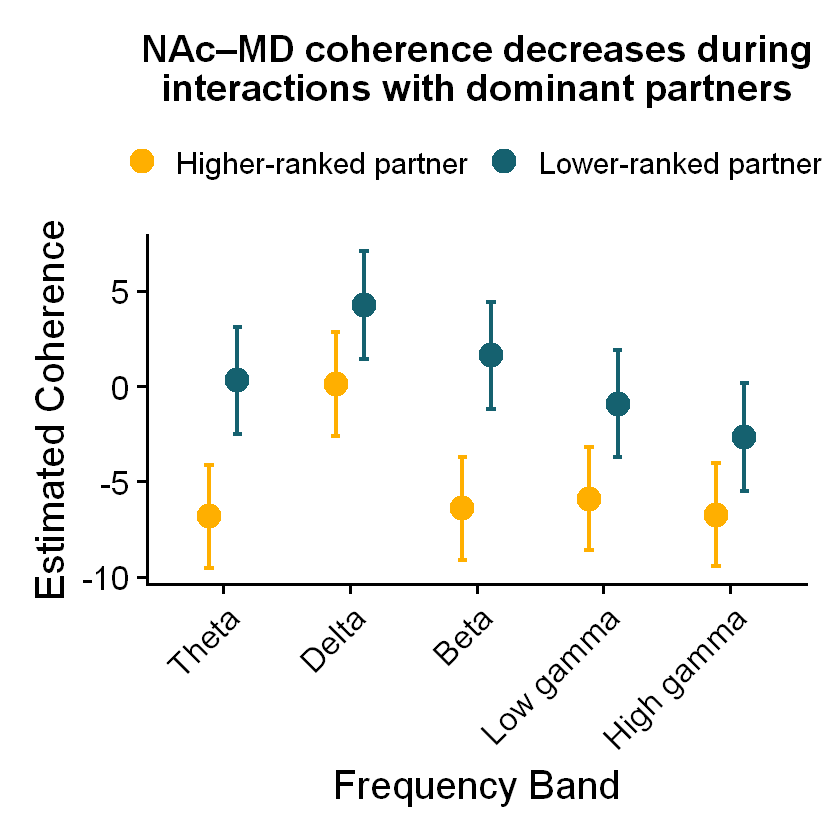

In [37]:
# --------------------------------------------------
# Create publication-style hierarchy coherence plot
# --------------------------------------------------

p <- ggplot(
    
    emm_df_filtered,
    
    aes(
        x = band,
        y = emmean,
        color = relative_rank
    )
) +

# estimated means
geom_point(
    
    position =
        position_dodge(width = 0.45),
    
    size = 6
) +

# confidence intervals
geom_errorbar(
    
    aes(
        ymin = asymp.LCL,
        ymax = asymp.UCL
    ),
    
    position =
        position_dodge(width = 0.45),
    
    width = 0.15,
    
    linewidth = 1.4
) +

# custom colors
scale_color_manual(
    
    values = c(
        
        "Higher-ranked partner" = "#ffaf00",
        
        "Lower-ranked partner" = "#15616f"
    )
) +

# labels
labs(
    
    title =
        "NAc–MD coherence decreases during\ninteractions with dominant partners",
    
    x = "Frequency Band",
    
    y = "Estimated Coherence",
    
    color = NULL
) +

# cleaner theme
theme_classic(
    base_size = 24
) +

theme(
    
    # centered title
    plot.title =
        element_text(
            face = "bold",
            size = 22,
            hjust = 0.5
        ),
    
    # axis titles
    axis.title =
        element_text(
            size = 24
        ),
    
    # tick labels
    axis.text =
        element_text(
            size = 20,
            color = "black"
        ),
    
    axis.text.x =
        element_text(
            angle = 45,
            hjust = 1
        ),
    
    # legend on top
    legend.position = "top",
    
    legend.text =
        element_text(
            size = 18
        ),
    
    # spacing
    plot.margin =
        margin(20,20,20,20)
)

p

In [38]:
# --------------------------------------------------
# Subset MD_vHPC data
# --------------------------------------------------

test_df <- coh_df |>
    
    filter(
        region_or_pair == "MD_vHPC",
        
        relative_rank != "equal_rank"
    )

In [39]:
# --------------------------------------------------
# Fit mixed model
# --------------------------------------------------

model <- lmer(
    
    value ~
        relative_rank * band +
        velocity_mouse1 +
        event_length +
        (1 | recording),

    data = test_df
)

Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."


In [40]:
# --------------------------------------------------
# Type III ANOVA
# --------------------------------------------------

anova(model)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
relative_rank,5693.15805,5693.15805,1,986.7312,22.0509524,3.030510e-06
band,14422.04796,3605.51199,4,5999.9749,13.9650037,2.419537e-11
velocity_mouse1,1079.37779,1079.37779,1,6012.9975,4.1806864,4.093059e-02
event_length,19.96681,19.96681,1,6010.8916,0.0773362,7.809499e-01
relative_rank:band,5980.03045,1495.00761,4,5999.9749,5.7905193,1.197508e-04


In [41]:
emm <- emmeans(
    
    model,
    
    ~ relative_rank | band
)

pairs(emm)

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 6025' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 6025)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 6025' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 6025)' or larger];
but be warned that this may result in large computation time and memory use.



band = Beta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject     7.18 1.63 Inf   4.404 <0.0001

band = Delta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject     7.63 1.63 Inf   4.679 <0.0001

band = High gamma:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject     6.99 1.63 Inf   4.283 <0.0001

band = Low gamma:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject     8.44 1.63 Inf   5.174 <0.0001

band = Theta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject     2.72 1.63 Inf   1.670  0.0949

Degrees-of-freedom method: asymptotic 

In [42]:
# --------------------------------------------------
# Convert emmeans to dataframe
# --------------------------------------------------

emm_df <- as.data.frame(emm)

In [43]:
# --------------------------------------------------
# Remove equal-rank interactions
# --------------------------------------------------

emm_df_filtered <- emm_df |>

    filter(
        relative_rank != "equal_rank"
    )

In [44]:
# --------------------------------------------------
# Reorder frequency bands
# --------------------------------------------------

emm_df_filtered$band <- factor(

    emm_df_filtered$band,

    levels = c(
        "Theta",
        "Delta",
        "Beta",
        "Low gamma",
        "High gamma"
    )
)

In [45]:
# --------------------------------------------------
# Rename hierarchy labels
# --------------------------------------------------

emm_df_filtered$relative_rank <- recode(

    emm_df_filtered$relative_rank,

    "higher_than_subject" =
        "Higher-ranked partner",

    "lower_than_subject" =
        "Lower-ranked partner"
)

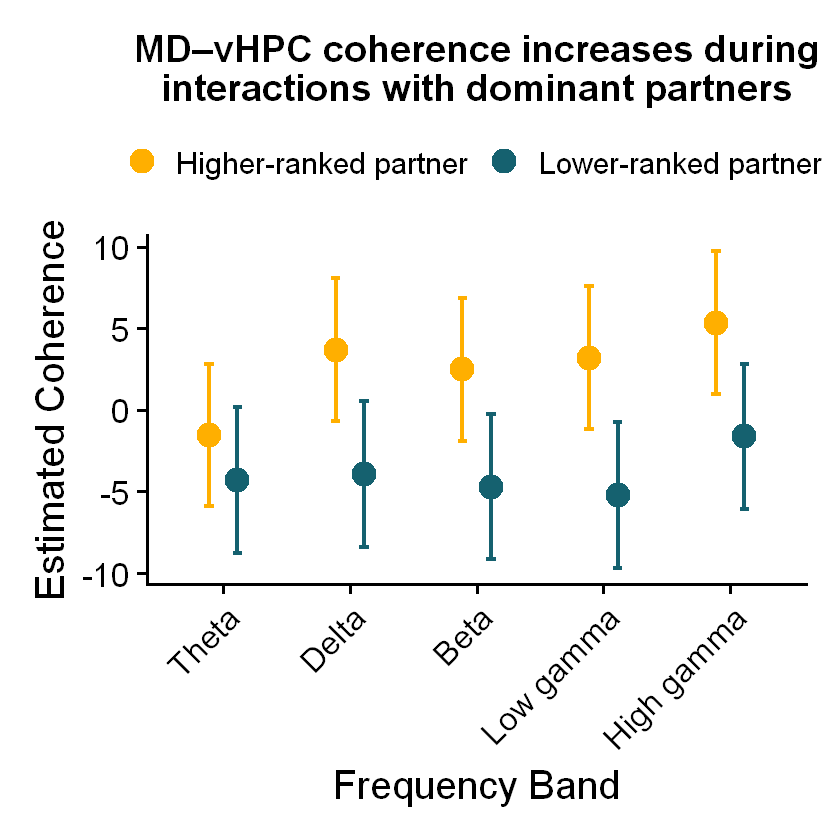

In [46]:
# --------------------------------------------------
# Create publication-style hierarchy coherence plot
# --------------------------------------------------

p <- ggplot(
    
    emm_df_filtered,
    
    aes(
        x = band,
        y = emmean,
        color = relative_rank
    )
) +

# estimated means
geom_point(
    
    position =
        position_dodge(width = 0.45),
    
    size = 6
) +

# confidence intervals
geom_errorbar(
    
    aes(
        ymin = asymp.LCL,
        ymax = asymp.UCL
    ),
    
    position =
        position_dodge(width = 0.45),
    
    width = 0.15,
    
    linewidth = 1.4
) +

# custom colors
scale_color_manual(
    
    values = c(
        
        "Higher-ranked partner" = "#ffaf00",
        
        "Lower-ranked partner" = "#15616f"
    )
) +

# labels
labs(
    
    title =
        "MD–vHPC coherence increases during\ninteractions with dominant partners",
    
    x = "Frequency Band",
    
    y = "Estimated Coherence",
    
    color = NULL
) +

# cleaner theme
theme_classic(
    base_size = 24
) +

theme(
    
    # centered title
    plot.title =
        element_text(
            face = "bold",
            size = 22,
            hjust = 0.5
        ),
    
    # axis titles
    axis.title =
        element_text(
            size = 24
        ),
    
    # tick labels
    axis.text =
        element_text(
            size = 20,
            color = "black"
        ),
    
    axis.text.x =
        element_text(
            angle = 45,
            hjust = 1
        ),
    
    # legend on top
    legend.position = "top",
    
    legend.text =
        element_text(
            size = 18
        ),
    
    # spacing
    plot.margin =
        margin(20,20,20,20)
)

p

In [47]:
test_df <- coh_df |>

    filter(
        region_or_pair == "mPFC_MD",
        relative_rank != "equal_rank"
    )

model <- lmer(

    value ~

        relative_rank * band +

        velocity_mouse1 +

        event_length +

        (1 | recording),

    data = test_df
)

emm <- emmeans(
    model,
    ~ relative_rank | band
)

pairs(emm)

Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Warning message:
"Some predictor variables are on very different scales: consider rescaling. 
You may also use (g)lmerControl(autoscale = TRUE) to improve numerical stability."
Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 7250' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 7250)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 7250' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 7250)' or larger];
but be warned that this may result in large computation time and memory use.



band = Beta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject  -1.7544 1.22 Inf  -1.435  0.1514

band = Delta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject  -0.5014 1.22 Inf  -0.410  0.6818

band = High gamma:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject  -0.0659 1.22 Inf  -0.054  0.9570

band = Low gamma:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject  -0.7679 1.22 Inf  -0.628  0.5300

band = Theta:
 contrast                                 estimate   SE  df z.ratio p.value
 higher_than_subject - lower_than_subject  -5.1299 1.22 Inf  -4.195 <0.0001

Degrees-of-freedom method: asymptotic 